# FHFA HPI Drawdown, Recovery, and Monte Carlo Projection by MSA

This notebook shows a complete workflow for using FHFA House Price Index (HPI) data to:

1. Download and clean FHFA MSA/MSAD HPI data.
2. Identify historical house-price drawdown episodes.
3. Locate each episode's peak, trough, and recovery date.
4. Compare historical peak-to-trough and trough-to-recovery behaviour across regions.
5. Simulate future HPI paths with Monte Carlo methods using historical regional returns.
6. Produce plots and tables that help explain the data.

The modelling objective is to understand historical downside risk in regional house prices and use that history to build projection and stress-testing tools for home-equity products.


## Modelling logic

For each MSA:

- **Peak**: the previous highest observed HPI level.
- **Drawdown**: the percentage fall from that peak.

\[
\text{Drawdown}_t = \frac{\text{HPI}_t}{\text{Peak HPI}_t} - 1
\]

- **Trough**: the lowest HPI point during a drawdown episode.
- **Recovery date**: the first later date where HPI returns to or exceeds the old peak.
- **Peak-to-trough loss**: the percentage fall from peak to trough.
- **Trough-to-recovery time**: number of months from trough to recovery.

The Monte Carlo section then simulates possible future HPI paths using historical monthly log returns from the same MSA.


## Install and import packages

Run the install cell if needed. If your environment already has these packages, you can skip it.


In [1]:
# Uncomment if packages are missing.
# !pip install pandas numpy matplotlib requests

In [2]:
from __future__ import annotations

import argparse
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings for easier notebook reading.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# FHFA public master CSV endpoint.
FHFA_MASTER_CSV = "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

# Output folder for CSV files and plots.
OUTDIR = Path("fhfa_hpi_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

## 1. Load and clean FHFA HPI data

The function below downloads the FHFA master HPI file and standardizes the columns.

The important output columns are:

| Column | Meaning |
|---|---|
| `region_id` | MSA/MSAD code if available |
| `region` | Region or MSA name |
| `level` | Geographic level |
| `date` | Monthly or quarterly date |
| `hpi` | FHFA HPI index value |

The loader is intentionally flexible because public data files sometimes change column labels slightly.


In [3]:
def _clean_col(c: str) -> str:
    """Normalize column names so later code is robust to spacing/case changes."""
    return re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")


def load_fhfa_hpi(
    url: str = FHFA_MASTER_CSV,
    level_filter: tuple[str, ...] = ("msa", "msad"),
    prefer_monthly: bool = True,
) -> pd.DataFrame:
    """
    Download and standardize FHFA HPI data.

    Returns
    -------
    pd.DataFrame
        Standardized table with:
        region_id, region, level, date, hpi
    """
    raw = pd.read_csv(url)
    raw.columns = [_clean_col(c) for c in raw.columns]

    # Flexible column discovery because FHFA may change column labels over time.
    col_candidates = {
        "level": ["level", "geo_level", "place_level"],
        "region": ["place_name", "place", "area", "msa_name", "cbsa_name"],
        "region_id": ["place_id", "cbsa", "cbsa_code", "msa_code"],
        "year": ["yr", "year"],
        "period": ["period", "quarter", "month"],
        "frequency": ["frequency", "freq"],
        "hpi": ["index_sa", "index_nsa", "hpi", "index"],
    }

    def pick(name: str, required: bool = True) -> str | None:
        for c in col_candidates[name]:
            if c in raw.columns:
                return c
        if required:
            raise ValueError(f"Could not find required column for {name}. Available columns: {list(raw.columns)}")
        return None

    level_col = pick("level")
    region_col = pick("region")
    region_id_col = pick("region_id", required=False)
    year_col = pick("year")
    period_col = pick("period")
    freq_col = pick("frequency", required=False)

    # Prefer seasonally adjusted index if available.
    hpi_col = "index_sa" if "index_sa" in raw.columns else pick("hpi")

    df = raw.copy()

    # Keep only MSA/MSAD level records by default.
    if level_col:
        df = df[df[level_col].astype(str).str.lower().isin(level_filter)]

    # Prefer monthly records when the frequency column exists.
    if freq_col and prefer_monthly:
        monthly_mask = df[freq_col].astype(str).str.lower().str.contains(r"month|^m$")
        if monthly_mask.any():
            df = df[monthly_mask]

    df = df.rename(
        columns={
            region_col: "region",
            year_col: "year",
            period_col: "period",
            hpi_col: "hpi",
            level_col: "level",
        }
    )

    if region_id_col:
        df = df.rename(columns={region_id_col: "region_id"})
    else:
        df["region_id"] = df["region"].astype(str)

    df["hpi"] = pd.to_numeric(df["hpi"], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Convert FHFA periods like 1, 01, M01, or Q1 into dates.
    period_text = df["period"].astype(str).str.upper().str.strip()
    period_num = pd.to_numeric(period_text.str.extract(r"(\d+)")[0], errors="coerce")

    is_quarterly = period_text.str.contains("Q").any() or (period_num.dropna().max() <= 4)
    if is_quarterly:
        month = ((period_num - 1) * 3 + 1).clip(1, 12)
    else:
        month = period_num.clip(1, 12)

    df["date"] = pd.to_datetime(
        dict(
            year=df["year"].astype(float),
            month=month.astype(float),
            day=1,
        ),
        errors="coerce",
    )

    keep = ["region_id", "region", "level", "date", "hpi"]
    df = df[keep].dropna(subset=["region", "date", "hpi"])
    df = df.sort_values(["region", "date"]).drop_duplicates(["region", "date"], keep="last")

    return df.reset_index(drop=True)

In [4]:
# Download and inspect the data.
hpi = load_fhfa_hpi()
hpi.to_csv(OUTDIR / "fhfa_msa_hpi_clean.csv", index=False)

print(f"Rows: {len(hpi):,}")
print(f"Regions: {hpi['region'].nunique():,}")
print(f"Date range: {hpi['date'].min().date()} to {hpi['date'].max().date()}")

hpi.head()

/var/folders/0s/42dzycks4ybbp585r_453m100000gn/T/ipykernel_6338/1016168222.py:20: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(url)


Rows: 57,808
Regions: 410
Date range: 1991-01-01 to 2026-01-01


,region_id,region,level,date,hpi
0,10180,"Abilene, TX",MSA,1991-01-01,100.00
1,10180,"Abilene, TX",MSA,1991-04-01,105.06
2,10180,"Abilene, TX",MSA,1991-07-01,104.73
3,10180,"Abilene, TX",MSA,1991-10-01,95.06
4,10180,"Abilene, TX",MSA,1992-01-01,107.33


## 2. Drawdown calculation

This section computes a drawdown series for each region.

There are two variants:

1. **Running maximum drawdown**: peak is the highest HPI ever observed up to that date.
2. **Rolling maximum drawdown**: peak is the highest HPI over a limited rolling window.

For home-equity stress testing, the running maximum is usually easier to explain because it measures loss from the prior cycle peak. A rolling window can be useful when you want a more local, recent-cycle view.


In [5]:
@dataclass
class DrawdownConfig:
    # Minimum drawdown required to count an episode.
    # -0.05 means ignore drawdowns smaller than 5%.
    min_drawdown: float = -0.05

    # If rolling_window is None, use running all-time peak.
    # If rolling_window is an integer, use rolling peak over that many periods.
    rolling_window: int | None = None


def compute_drawdown_series(region_df: pd.DataFrame, rolling_window: int | None = None) -> pd.DataFrame:
    """
    Compute running or rolling peak and drawdown for one region.

    drawdown = HPI / peak - 1
    """
    s = region_df.sort_values("date").copy()

    if rolling_window is None:
        s["peak_hpi"] = s["hpi"].cummax()
    else:
        s["peak_hpi"] = s["hpi"].rolling(rolling_window, min_periods=1).max()

    s["drawdown"] = s["hpi"] / s["peak_hpi"] - 1.0
    return s

## 3. Identify peak, trough, and recovery events

The function below scans the drawdown series and records each drawdown event.

For each event, it stores:

- peak date and peak HPI
- trough date and trough HPI
- recovery date and recovery HPI
- peak-to-trough percentage loss
- months from peak to trough
- months from trough to recovery
- whether the region has recovered to the old peak


In [6]:
def _event_record(s: pd.DataFrame, peak_idx: int, trough_idx: int, recovery_idx: int | None) -> dict:
    """Create one row describing a drawdown event."""
    peak_date = s.loc[peak_idx, "date"]
    trough_date = s.loc[trough_idx, "date"]
    recovery_date = pd.NaT if recovery_idx is None else s.loc[recovery_idx, "date"]

    peak_hpi = float(s.loc[peak_idx, "hpi"])
    trough_hpi = float(s.loc[trough_idx, "hpi"])
    recovery_hpi = np.nan if recovery_idx is None else float(s.loc[recovery_idx, "hpi"])

    return {
        "peak_date": peak_date,
        "trough_date": trough_date,
        "recovery_date": recovery_date,
        "peak_hpi": peak_hpi,
        "trough_hpi": trough_hpi,
        "recovery_hpi": recovery_hpi,
        "peak_to_trough_pct": trough_hpi / peak_hpi - 1.0,
        "months_peak_to_trough": int(round((trough_date - peak_date).days / 30.4375)),
        "months_trough_to_recovery": np.nan
        if recovery_idx is None
        else int(round((recovery_date - trough_date).days / 30.4375)),
        "recovered": recovery_idx is not None,
    }


def find_drawdown_events(
    region_df: pd.DataFrame,
    config: DrawdownConfig = DrawdownConfig(),
) -> pd.DataFrame:
    """
    Identify drawdown episodes for one MSA.

    Event starts:
        when HPI is below the prior peak by at least min_drawdown.

    Trough:
        lowest HPI during the event.

    Recovery:
        first date after trough where HPI >= prior peak HPI.
    """
    s = compute_drawdown_series(region_df, config.rolling_window)
    s = s.sort_values("date").reset_index(drop=True)

    events = []
    in_event = False
    event_peak_idx = None
    event_trough_idx = None

    for i, row in s.iterrows():
        dd = row["drawdown"]

        if not in_event:
            if dd <= config.min_drawdown:
                in_event = True

                # The event peak is the most recent point where HPI equals the peak HPI.
                prior = s.iloc[: i + 1]
                matches = prior.index[np.isclose(prior["hpi"], row["peak_hpi"])]
                event_peak_idx = int(matches[-1]) if len(matches) else int(prior["hpi"].idxmax())
                event_trough_idx = i

        else:
            # Keep updating trough while the event is active.
            if row["hpi"] < s.loc[event_trough_idx, "hpi"]:
                event_trough_idx = i

            peak_hpi = s.loc[event_peak_idx, "hpi"]

            # Recovery happens when HPI returns to or exceeds the old peak.
            if row["hpi"] >= peak_hpi:
                events.append(_event_record(s, event_peak_idx, event_trough_idx, i))
                in_event = False
                event_peak_idx = None
                event_trough_idx = None

    # If the series ends while still below the old peak, mark the event unrecovered.
    if in_event:
        events.append(_event_record(s, event_peak_idx, event_trough_idx, None))

    out = pd.DataFrame(events)
    if not out.empty:
        out["region"] = s["region"].iloc[0]
        out["region_id"] = s["region_id"].iloc[0]
        out = out[
            [
                "region_id",
                "region",
                "peak_date",
                "trough_date",
                "recovery_date",
                "peak_hpi",
                "trough_hpi",
                "recovery_hpi",
                "peak_to_trough_pct",
                "months_peak_to_trough",
                "months_trough_to_recovery",
                "recovered",
            ]
        ]
    return out


def find_all_msa_drawdowns(
    hpi: pd.DataFrame,
    config: DrawdownConfig = DrawdownConfig(),
    min_history_periods: int = 60,
) -> pd.DataFrame:
    """Apply drawdown detection to every MSA/MSAD in the FHFA dataset."""
    rows = []
    for _, g in hpi.groupby("region", sort=False):
        if len(g) < min_history_periods:
            continue
        ev = find_drawdown_events(g, config)
        if not ev.empty:
            rows.append(ev)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [7]:
# Run historical drawdown detection for all regions.
config = DrawdownConfig(
    min_drawdown=-0.05,   # count episodes with at least 5% fall from prior peak
    rolling_window=None   # None means running maximum; use e.g. 120 for 10-year rolling monthly peak
)

events = find_all_msa_drawdowns(hpi, config=config)
events.to_csv(OUTDIR / "drawdown_events_by_msa.csv", index=False)

print(f"Drawdown events found: {len(events):,}")
events.head()

Drawdown events found: 732


,region_id,region,peak_date,trough_date,recovery_date,peak_hpi,trough_hpi,recovery_hpi,peak_to_trough_pct,months_peak_to_trough,months_trough_to_recovery,recovered
0,10180,"Abilene, TX",1991-04-01,1991-10-01,1992-01-01,105.06,95.06,107.33,-0.095184,6,3.0,True
1,10420,"Akron, OH",2005-01-01,2011-04-01,2019-10-01,189.81,123.91,191.20,-0.347189,75,102.0,True
2,10500,"Albany, GA",2007-01-01,2015-07-01,2021-04-01,163.61,122.17,172.33,-0.253285,102,69.0,True
3,10540,"Albany, OR",2007-10-01,2011-04-01,2016-04-01,334.81,241.82,336.32,-0.277740,42,60.0,True
4,10580,"Albany-Schenectady-Troy, NY",1992-01-01,1998-04-01,2001-04-01,102.85,90.54,103.84,-0.119689,75,36.0,True


## 4. Worst historical peak-to-trough drawdowns

This table ranks the deepest drawdowns across MSAs.

Interpretation:

- More negative `peak_to_trough_pct` means a deeper house-price fall.
- Long `months_trough_to_recovery` means the region stayed underwater for longer.
- `recovered = False` means the index had not recovered to the prior peak by the end of the data.


In [8]:
worst_20 = (
    events.sort_values("peak_to_trough_pct")
    .head(20)
    [
        [
            "region",
            "peak_date",
            "trough_date",
            "recovery_date",
            "peak_to_trough_pct",
            "months_peak_to_trough",
            "months_trough_to_recovery",
            "recovered",
        ]
    ]
)

worst_20.to_csv(OUTDIR / "worst_20_drawdowns.csv", index=False)
worst_20

,region,peak_date,trough_date,recovery_date,peak_to_trough_pct,months_peak_to_trough,months_trough_to_recovery,recovered
405,"Merced, CA",2006-04-01,2009-07-01,2021-04-01,-0.656842,39,141.0,True
423,"Modesto, CA",2006-01-01,2011-07-01,2021-01-01,-0.639349,66,114.0,True
363,"Las Vegas-Henderson-North Las Vegas, NV",2006-01-01,2012-01-01,2020-10-01,-0.628462,72,105.0,True
620,"Stockton-Lodi, CA",2005-07-01,2011-04-01,2021-01-01,-0.600573,69,117.0,True
662,"Vallejo, CA",2006-01-01,2011-10-01,2021-01-01,-0.594584,69,111.0,True
191,"Flint, MI",2005-04-01,2011-10-01,2021-01-01,-0.589302,78,111.0,True
94,"Cape Coral-Fort Myers, FL",2006-07-01,2011-01-01,2021-01-01,-0.585258,54,120.0,True
524,"Reno, NV",2006-01-01,2011-10-01,2019-04-01,-0.583453,69,90.0,True
544,"Salinas, CA",2005-10-01,2011-07-01,2021-04-01,-0.582539,69,117.0,True
729,"Yuba City, CA",2006-01-01,2012-01-01,2020-10-01,-0.580078,72,105.0,True


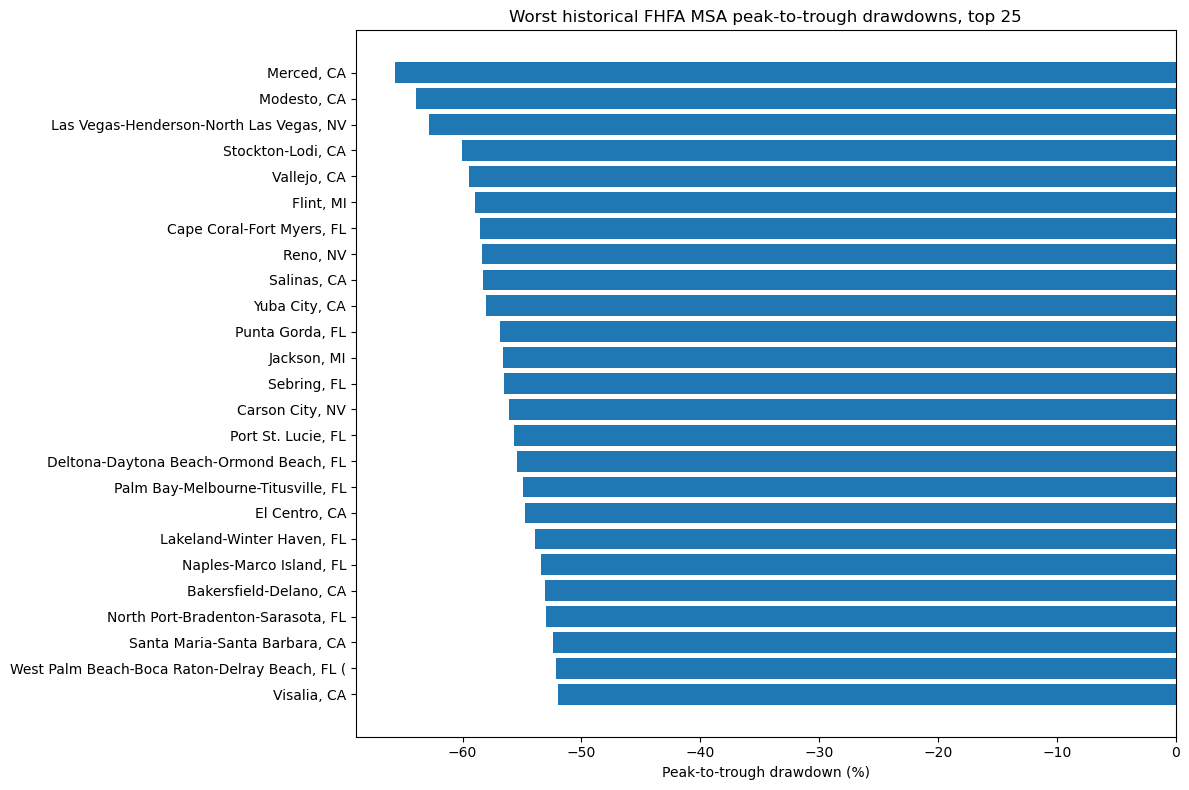

In [9]:
def plot_top_drawdowns(events: pd.DataFrame, top_n: int = 25) -> None:
    """Plot the worst historical MSA peak-to-trough drawdowns."""
    e = events.sort_values("peak_to_trough_pct").head(top_n).copy()
    e["label"] = e["region"].str.slice(0, 45)
    e["drawdown_pct"] = e["peak_to_trough_pct"] * 100

    fig, ax = plt.subplots(figsize=(12, max(6, top_n * 0.32)))
    ax.barh(e["label"], e["drawdown_pct"])
    ax.set_title(f"Worst historical FHFA MSA peak-to-trough drawdowns, top {top_n}")
    ax.set_xlabel("Peak-to-trough drawdown (%)")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

plot_top_drawdowns(events, top_n=25)

## 5. Plot HPI and drawdown for selected regions

Choose regions to examine in detail.

You can change `selected_regions` to any MSA names found in the FHFA file. The helper below supports partial matching.


In [10]:
def choose_regions(hpi: pd.DataFrame, requested: Iterable[str] | None, n_default: int = 5) -> list[str]:
    """Find MSA names using exact or partial matching."""
    regions = sorted(hpi["region"].dropna().unique())

    if requested:
        chosen = []
        lower_map = {r.lower(): r for r in regions}
        for item in requested:
            item_l = item.lower()
            exact = lower_map.get(item_l)

            if exact:
                chosen.append(exact)
                continue

            fuzzy = [r for r in regions if item_l in r.lower()]
            if fuzzy:
                chosen.append(fuzzy[0])
            else:
                print(f"WARNING: Region not found: {item}")

        return list(dict.fromkeys(chosen))

    preferred_terms = [
        "New York",
        "Los Angeles",
        "Miami",
        "Phoenix",
        "Las Vegas",
        "San Francisco",
        "Dallas",
    ]

    chosen = []
    for term in preferred_terms:
        hit = [r for r in regions if term.lower() in r.lower()]
        if hit:
            chosen.append(hit[0])

    return list(dict.fromkeys(chosen))[:n_default] or regions[:n_default]


selected_regions = choose_regions(
    hpi,
    requested=[
        "Phoenix",
        "Miami",
        "Las Vegas",
        "San Francisco",
        "New York",
    ],
)

selected_regions

['Phoenix-Mesa-Chandler, AZ',
 'Miami-Miami Beach-Kendall, FL (MSAD)',
 'Las Vegas-Henderson-North Las Vegas, NV',
 'San Francisco-San Mateo-Redwood City, CA (MSAD)',
 'New York-Jersey City-White Plains, NY-NJ (MSAD)']

In [23]:
hpi
df = hpi[hpi["region"] == region].copy().head(2)
df.head(2)

In [24]:
s = compute_drawdown_series(df)
region = s["region"].iloc[0]
s


,region_id,region,level,date,hpi,peak_hpi,drawdown
37081,35614,"New York-Jersey City-White Plains, NY-NJ (MSAD)",MSA,1991-01-01,100.00,100.0,0.0000
37082,35614,"New York-Jersey City-White Plains, NY-NJ (MSAD)",MSA,1991-04-01,99.72,100.0,-0.0028


In [26]:
local_events = events[events["region"] == region].copy()
local_events 

,region_id,region,peak_date,trough_date,recovery_date,peak_hpi,trough_hpi,recovery_hpi,peak_to_trough_pct,months_peak_to_trough,months_trough_to_recovery,recovered
455,35614,"New York-Jersey City-White Plains, NY-NJ (MSAD)",2006-07-01,2012-04-01,2018-01-01,271.06,217.45,276.23,-0.197779,69,69.0,True


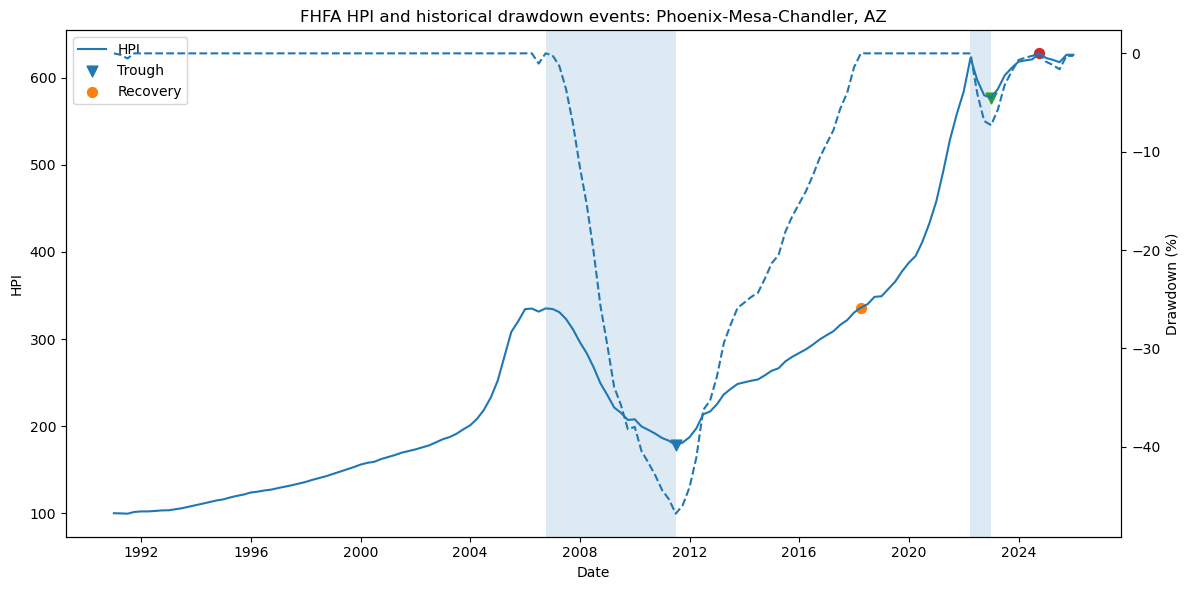

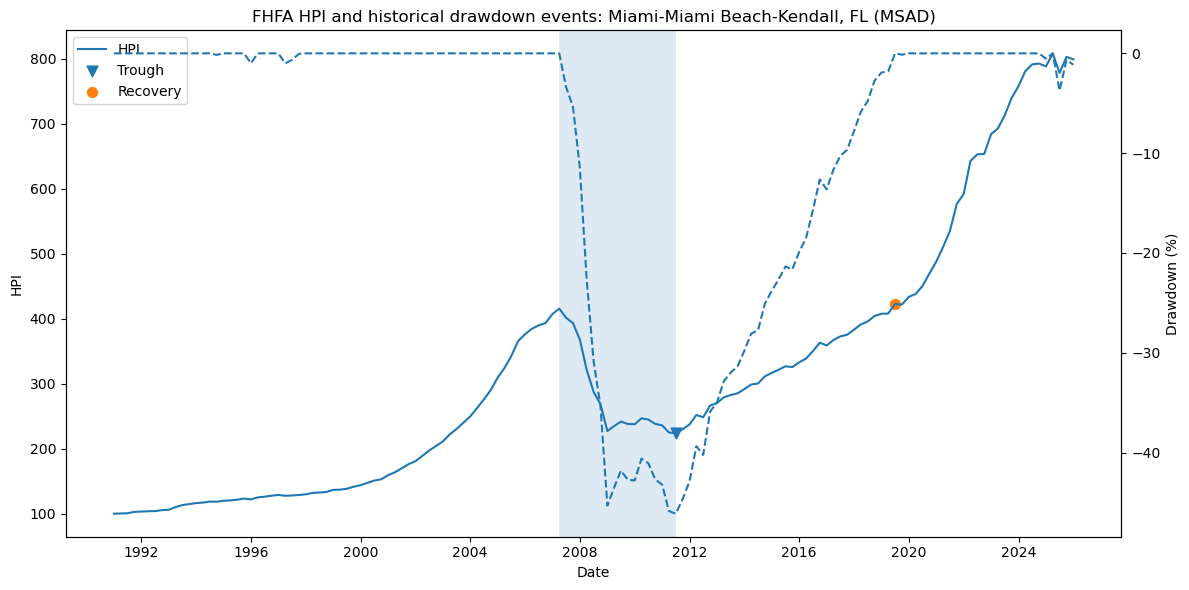

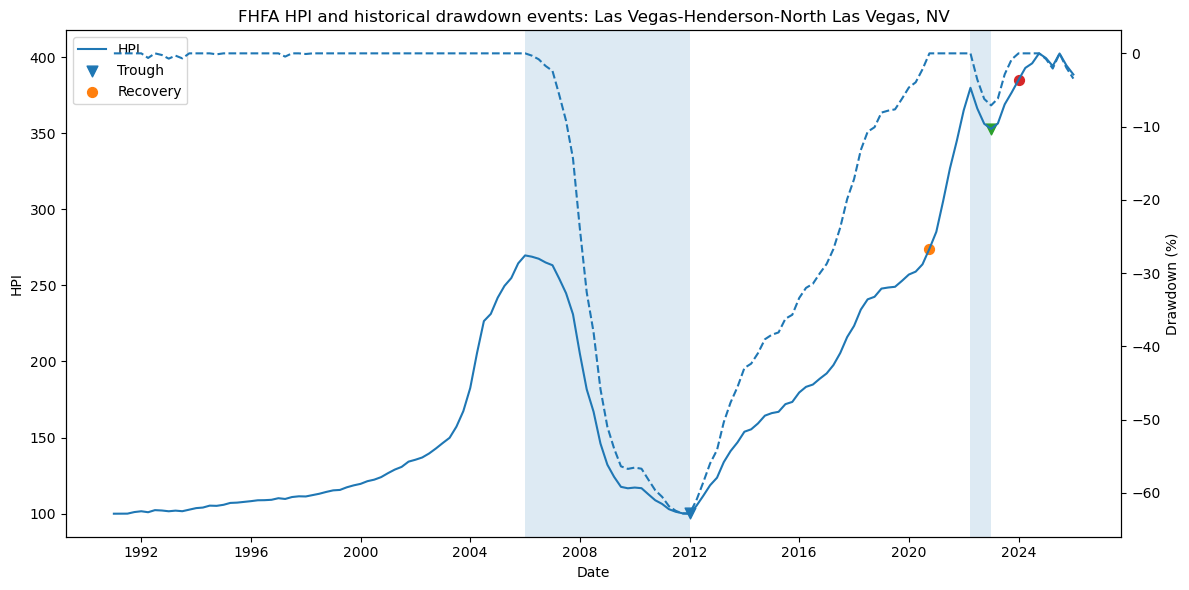

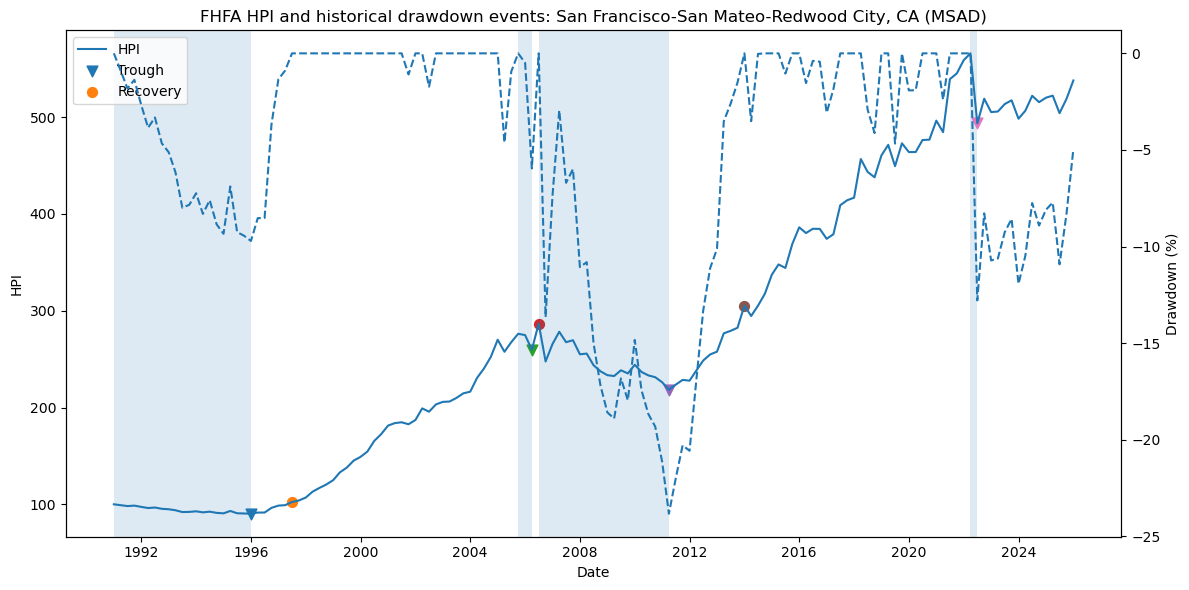

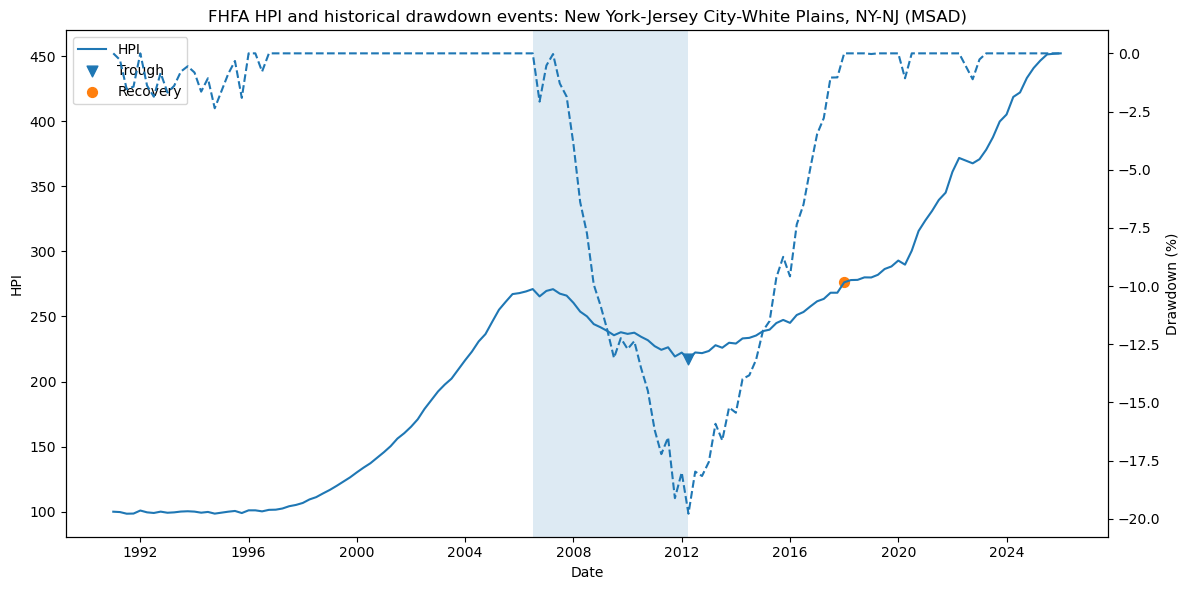

In [11]:
def plot_region_hpi_and_drawdown(region_df: pd.DataFrame, events: pd.DataFrame) -> None:
    """Plot HPI, drawdown, troughs, and recovery points for one region."""
    s = compute_drawdown_series(region_df)
    region = s["region"].iloc[0]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # HPI level.
    ax1.plot(s["date"], s["hpi"], label="HPI")
    ax1.set_title(f"FHFA HPI and historical drawdown events: {region}")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("HPI")

    # Highlight drawdown windows and mark trough/recovery points.
    local_events = events[events["region"] == region].copy()
    for _, e in local_events.iterrows():
        ax1.axvspan(e["peak_date"], e["trough_date"], alpha=0.15)
        ax1.scatter(e["trough_date"], e["trough_hpi"], marker="v", s=60, label="Trough" if _ == local_events.index[0] else None)

        if pd.notna(e["recovery_date"]):
            ax1.scatter(e["recovery_date"], e["recovery_hpi"], marker="o", s=50, label="Recovery" if _ == local_events.index[0] else None)

    # Drawdown percentage on second axis.
    ax2 = ax1.twinx()
    ax2.plot(s["date"], s["drawdown"] * 100, linestyle="--", label="Drawdown %")
    ax2.set_ylabel("Drawdown (%)")

    ax1.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


for region in selected_regions:
    g = hpi[hpi["region"] == region].copy()
    plot_region_hpi_and_drawdown(g, events)

## 6. Monte Carlo simulation using historical HPI returns

The Monte Carlo model uses historical monthly log returns from each MSA.

Two simulation methods are included:

### Bootstrap method

Randomly resamples historical monthly returns with replacement.

Advantages:
- Keeps the empirical distribution.
- Better preserves fat tails and skew than a normal model.
- Simple and transparent.

Disadvantages:
- Assumes historical return distribution is representative.
- Does not explicitly model macro regimes.
- May understate risk if the historical sample does not include enough stress.

### GBM method

Estimates mean and volatility of historical log returns and samples normally distributed shocks.

Advantages:
- Simple, smooth, and common in finance.
- Easy to parameterize.

Disadvantages:
- Normal shocks may understate tail risk.
- Does not naturally capture housing-market serial correlation or long recovery cycles.


In [12]:
def simulate_hpi_paths(
    region_df: pd.DataFrame,
    horizon_months: int = 120,
    n_sims: int = 2000,
    method: str = "bootstrap",
    seed: int = 42,
) -> pd.DataFrame:
    """
    Simulate future HPI paths for one region.

    method='bootstrap':
        Resample historical monthly log returns with replacement.

    method='gbm':
        Estimate mean and standard deviation of historical log returns and sample normal returns.
    """
    rng = np.random.default_rng(seed)

    s = region_df.sort_values("date").copy()
    s["log_return"] = np.log(s["hpi"]).diff()
    returns = s["log_return"].dropna().to_numpy()

    if len(returns) < 24:
        raise ValueError("Need at least 24 returns for Monte Carlo simulation.")

    last_hpi = float(s["hpi"].iloc[-1])
    last_date = s["date"].iloc[-1]

    future_dates = pd.date_range(
        last_date + pd.offsets.MonthBegin(1),
        periods=horizon_months,
        freq="MS",
    )

    if method == "bootstrap":
        shocks = rng.choice(returns, size=(horizon_months, n_sims), replace=True)
    elif method == "gbm":
        mu = np.mean(returns)
        sigma = np.std(returns, ddof=1)
        shocks = rng.normal(mu, sigma, size=(horizon_months, n_sims))
    else:
        raise ValueError("method must be 'bootstrap' or 'gbm'")

    log_paths = np.log(last_hpi) + np.cumsum(shocks, axis=0)
    paths = np.exp(log_paths)

    out = pd.DataFrame(paths, index=future_dates)
    out.index.name = "date"
    out.columns = [f"sim_{i+1}" for i in range(n_sims)]

    return out

In [13]:
def summarize_mc_drawdowns(paths: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate max drawdown and recovery information for each simulated path.

    Recovery in this function means the simulated HPI recovers to the starting simulated level.
    """
    start_level = paths.iloc[0]
    summaries = []

    for col in paths.columns:
        x = paths[col]
        running_peak = x.cummax()
        drawdown = x / running_peak - 1.0

        trough_date = drawdown.idxmin()
        max_dd = float(drawdown.min())
        trough_hpi = float(x.loc[trough_date])

        recovered_after_trough = x.loc[trough_date:][x.loc[trough_date:] >= start_level[col]]
        recovery_date = pd.NaT if recovered_after_trough.empty else recovered_after_trough.index[0]

        summaries.append(
            {
                "simulation": col,
                "max_drawdown_pct": max_dd,
                "trough_date": trough_date,
                "trough_hpi": trough_hpi,
                "recovery_to_start_date": recovery_date,
                "months_trough_to_recovery": np.nan
                if pd.isna(recovery_date)
                else int(round((recovery_date - trough_date).days / 30.4375)),
                "recovered_to_start": not pd.isna(recovery_date),
            }
        )

    return pd.DataFrame(summaries)


def plot_mc_fan(paths: pd.DataFrame, region: str) -> None:
    """Fan chart showing simulated HPI percentiles."""
    q = paths.quantile([0.05, 0.25, 0.50, 0.75, 0.95], axis=1).T

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(q.index, q[0.50], label="Median")
    ax.fill_between(q.index, q[0.25], q[0.75], alpha=0.25, label="25th-75th percentile")
    ax.fill_between(q.index, q[0.05], q[0.95], alpha=0.15, label="5th-95th percentile")
    ax.set_title(f"Monte Carlo FHFA HPI fan chart: {region}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Simulated HPI")
    ax.legend()
    fig.tight_layout()
    plt.show()

## 7. Run Monte Carlo for selected regions

The summary table reports:

- **median simulated max drawdown**
- **5th percentile max drawdown**, interpreted as a severe downside simulation outcome
- **probability of recovery to starting level**
- **median months from trough to recovery**

Note that Monte Carlo projection is not a deterministic prediction. It is a distribution of possible paths conditioned on historical return behaviour.


Running Monte Carlo for: Phoenix-Mesa-Chandler, AZ


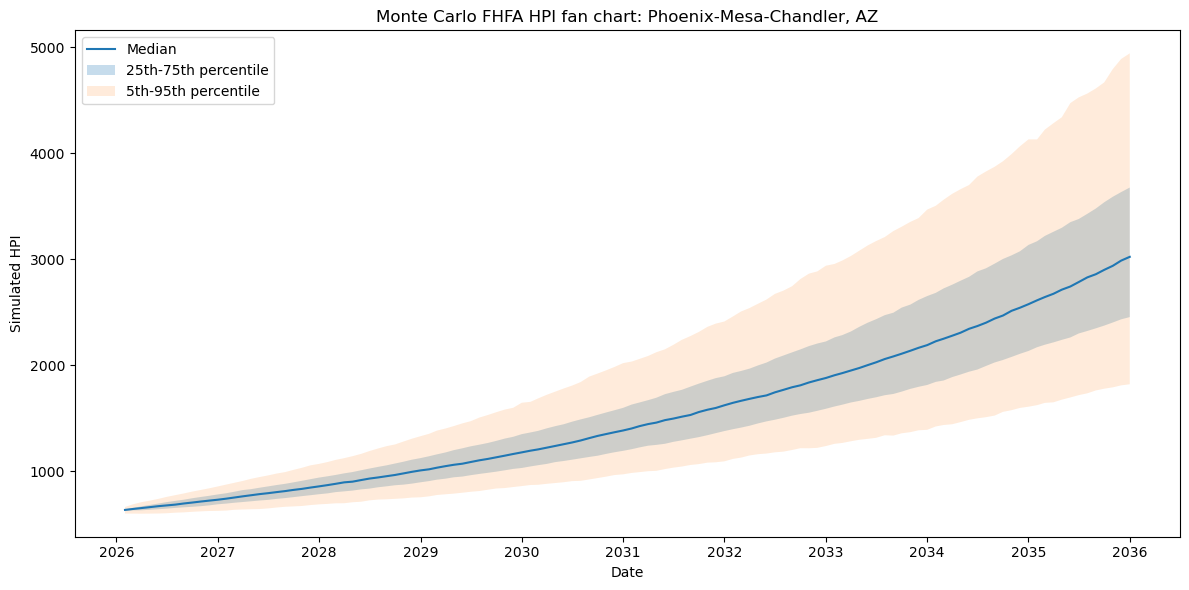

Running Monte Carlo for: Miami-Miami Beach-Kendall, FL (MSAD)


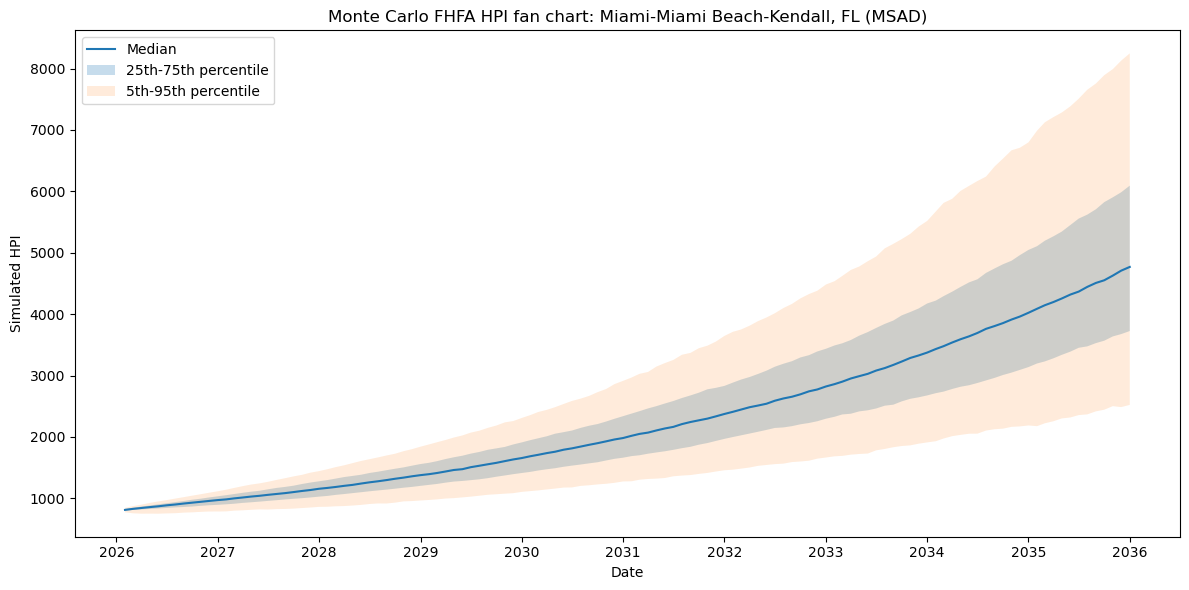

Running Monte Carlo for: Las Vegas-Henderson-North Las Vegas, NV


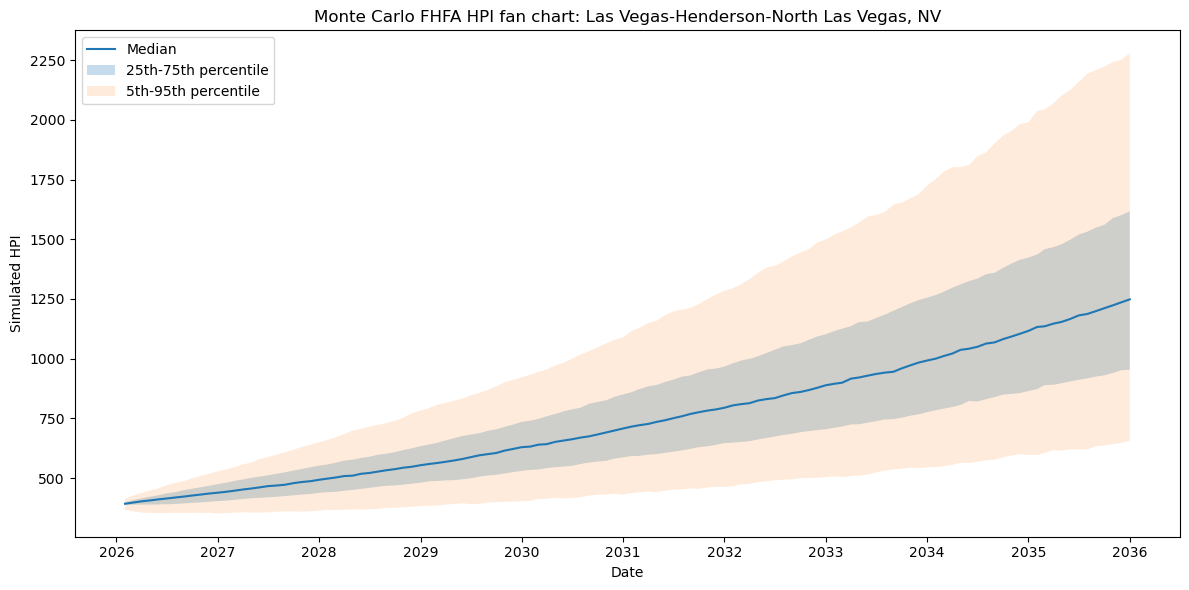

Running Monte Carlo for: San Francisco-San Mateo-Redwood City, CA (MSAD)


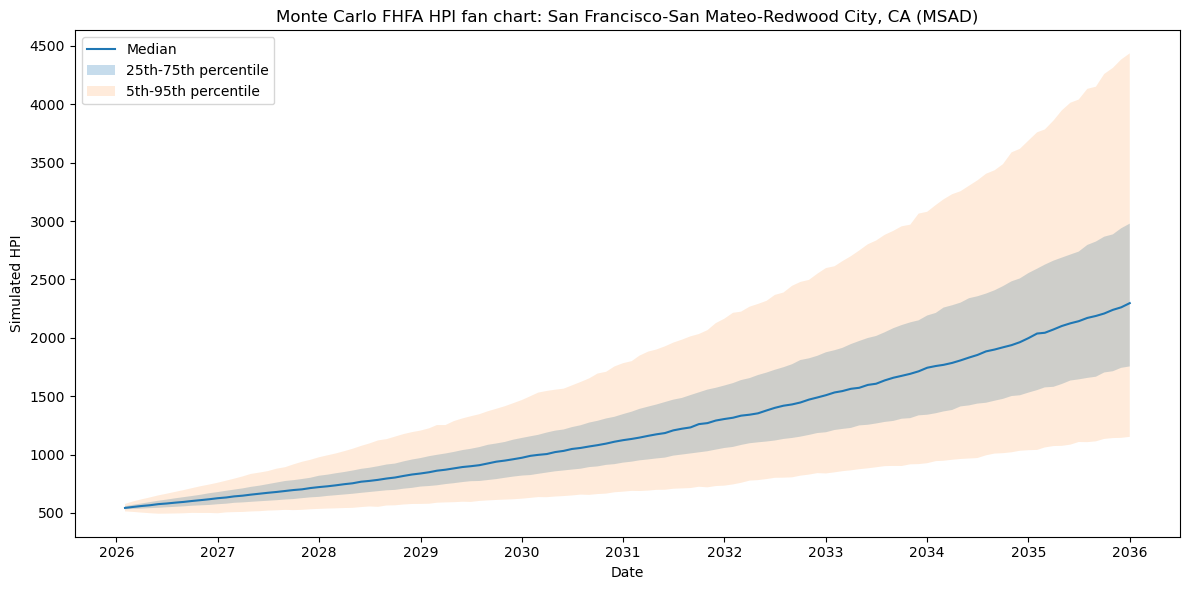

Running Monte Carlo for: New York-Jersey City-White Plains, NY-NJ (MSAD)


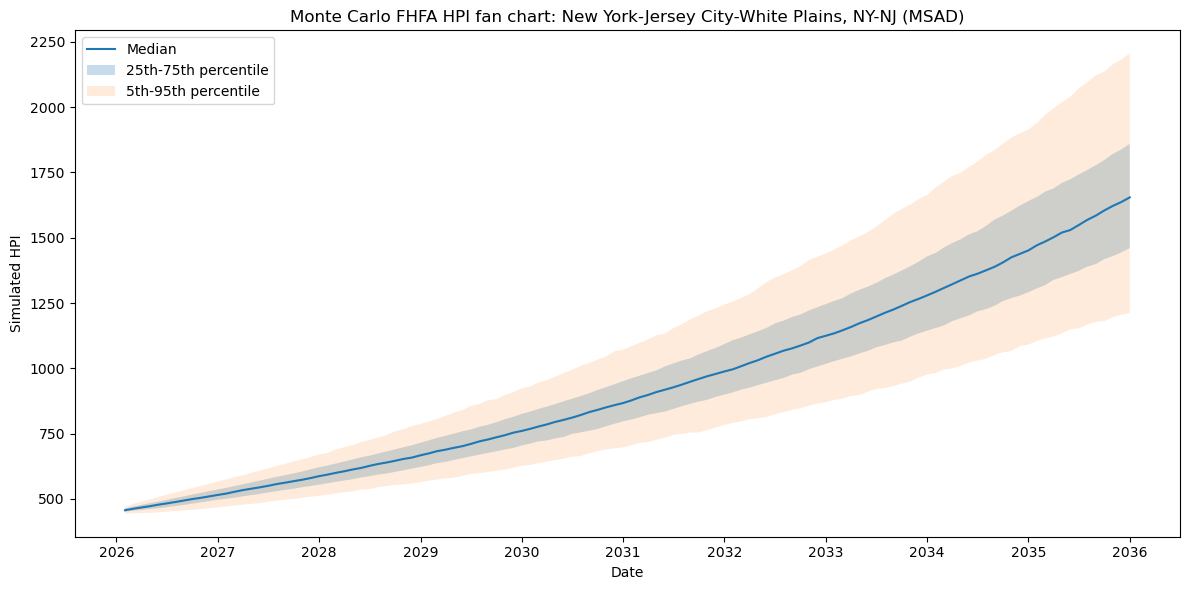

,region,median_mc_max_drawdown,p5_mc_max_drawdown,recovery_probability,median_months_trough_to_recovery
0,"Las Vegas-Henderson-North Las Vegas, NV",-0.186419,-0.317610,0.9995,0.0
1,"Miami-Miami Beach-Kendall, FL (MSAD)",-0.157077,-0.285017,1.0000,0.0
2,"New York-Jersey City-White Plains, NY-NJ (MSAD)",-0.045675,-0.076052,1.0000,0.0
3,"Phoenix-Mesa-Chandler, AZ",-0.099843,-0.170682,1.0000,0.0
4,"San Francisco-San Mateo-Redwood City, CA (MSAD)",-0.170648,-0.300800,1.0000,0.0


In [14]:
HORIZON_MONTHS = 120
N_SIMS = 2000
MC_METHOD = "bootstrap"  # change to "gbm" to compare normal-return model

all_mc_summaries = []

for region in selected_regions:
    g = hpi[hpi["region"] == region].copy()

    print(f"Running Monte Carlo for: {region}")
    paths = simulate_hpi_paths(
        g,
        horizon_months=HORIZON_MONTHS,
        n_sims=N_SIMS,
        method=MC_METHOD,
        seed=42,
    )

    # Save paths if you want to inspect or reuse them later.
    safe_region = re.sub(r"[^a-zA-Z0-9]+", "_", region).strip("_")[:80]
    paths.to_csv(OUTDIR / f"{safe_region}_mc_paths.csv")

    plot_mc_fan(paths, region)

    mc_summary = summarize_mc_drawdowns(paths)
    mc_summary["region"] = region
    all_mc_summaries.append(mc_summary)

mc_all = pd.concat(all_mc_summaries, ignore_index=True)
mc_all.to_csv(OUTDIR / "mc_drawdown_summary_all_selected_regions.csv", index=False)

mc_region_summary = (
    mc_all.groupby("region")
    .agg(
        median_mc_max_drawdown=("max_drawdown_pct", "median"),
        p5_mc_max_drawdown=("max_drawdown_pct", lambda x: x.quantile(0.05)),
        recovery_probability=("recovered_to_start", "mean"),
        median_months_trough_to_recovery=("months_trough_to_recovery", "median"),
    )
    .reset_index()
)

mc_region_summary.to_csv(OUTDIR / "mc_region_summary.csv", index=False)
mc_region_summary

## 8. Compare historical drawdown with Monte Carlo downside estimates

This comparison is useful for model governance:

- Historical analysis tells you what actually happened in observed downturns.
- Monte Carlo estimates a distribution of possible future outcomes.
- If the Monte Carlo downside is materially less severe than historical crisis drawdowns, the simulation may be under-calibrated for stress testing.


In [15]:
# Historical worst drawdown for selected regions.
hist_summary = (
    events[events["region"].isin(selected_regions)]
    .groupby("region")
    .agg(
        historical_worst_drawdown=("peak_to_trough_pct", "min"),
        historical_median_drawdown=("peak_to_trough_pct", "median"),
        historical_max_recovery_months=("months_trough_to_recovery", "max"),
        historical_recovery_rate=("recovered", "mean"),
    )
    .reset_index()
)

comparison = hist_summary.merge(mc_region_summary, on="region", how="left")
comparison

,region,historical_worst_drawdown,historical_median_drawdown,historical_max_recovery_months,historical_recovery_rate,median_mc_max_drawdown,p5_mc_max_drawdown,recovery_probability,median_months_trough_to_recovery
0,"Las Vegas-Henderson-North Las Vegas, NV",-0.628462,-0.349750,105.0,1.00,-0.186419,-0.317610,0.9995,0.0
1,"Miami-Miami Beach-Kendall, FL (MSAD)",-0.461259,-0.461259,96.0,1.00,-0.157077,-0.285017,1.0000,0.0
2,"New York-Jersey City-White Plains, NY-NJ (MSAD)",-0.197779,-0.197779,69.0,1.00,-0.045675,-0.076052,1.0000,0.0
3,"Phoenix-Mesa-Chandler, AZ",-0.468033,-0.270521,81.0,1.00,-0.099843,-0.170682,1.0000,0.0
4,"San Francisco-San Mateo-Redwood City, CA (MSAD)",-0.238271,-0.112478,33.0,0.75,-0.170648,-0.300800,1.0000,0.0


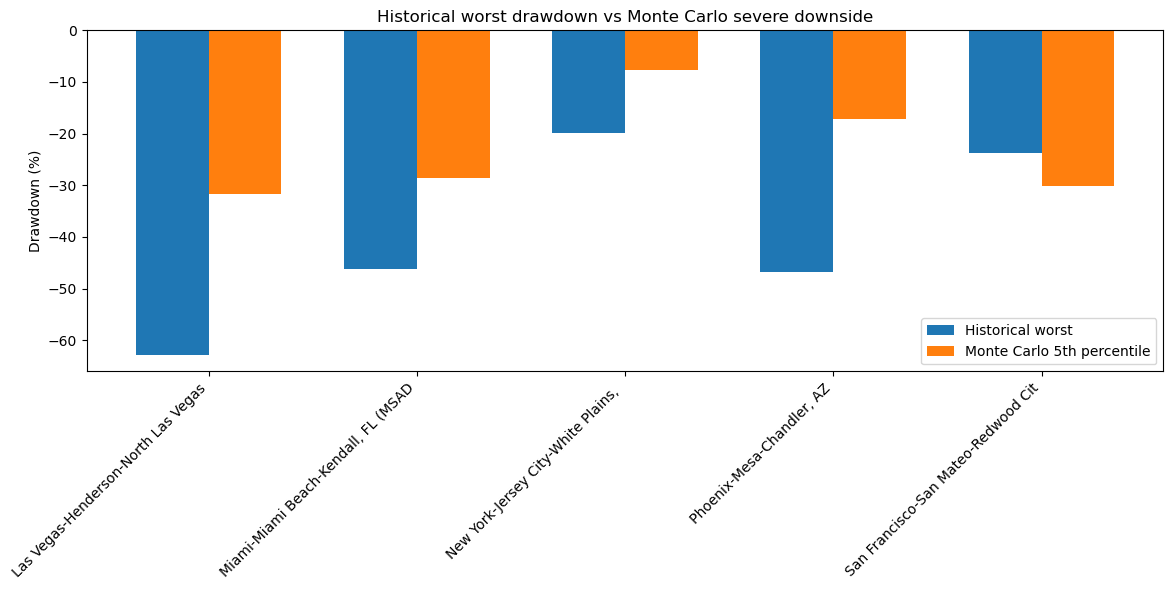

In [16]:
def plot_historical_vs_mc(comparison: pd.DataFrame) -> None:
    """Compare historical worst drawdown with simulated downside estimate."""
    c = comparison.copy()
    c["historical_worst_drawdown_pct"] = c["historical_worst_drawdown"] * 100
    c["p5_mc_max_drawdown_pct"] = c["p5_mc_max_drawdown"] * 100

    labels = c["region"].str.slice(0, 35)
    x = np.arange(len(c))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width / 2, c["historical_worst_drawdown_pct"], width, label="Historical worst")
    ax.bar(x + width / 2, c["p5_mc_max_drawdown_pct"], width, label="Monte Carlo 5th percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Drawdown (%)")
    ax.set_title("Historical worst drawdown vs Monte Carlo severe downside")
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_historical_vs_mc(comparison)

## 9. Conclusions and modelling interpretation

### What the historical drawdown model is good for

The historical peak-to-trough method is best for:

- clear regional stress curves
- credit-policy assumptions
- explainable home-equity valuation haircuts
- deterministic scenario design
- model governance and back-testing

It is transparent because every stress event maps to observed FHFA HPI history.

### What Monte Carlo is good for

Monte Carlo is best for:

- probability distributions of future outcomes
- downside percentiles
- expected loss modelling
- sensitivity analysis
- comparing regions on risk uncertainty

It is not automatically better than historical stress. It depends heavily on the return process, calibration window, and whether the simulation captures housing-cycle persistence.

### Practical recommendation

For home-equity projection:

1. Use historical drawdown/recovery analysis to define deterministic regional stress curves.
2. Use Monte Carlo to test whether those deterministic curves are conservative enough.
3. Compare historical worst drawdown against Monte Carlo downside percentiles.
4. Add expert or macroeconomic overlays where FHFA history may not fully represent future risk.

A strong production model usually combines both:

\[
\text{Historical stress curve} + \text{Monte Carlo validation} + \text{macro overlay}
\]
